In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [2]:
file = "/home/zhe2/data/PACE/adding_sif_output/PACE_OCI.20250927T123954.L1B.V3_adding_sif_p5_20260320.nc"
ds = xr.open_dataset(file)
ds

<xarray.Dataset> Size: 907MB
Dimensions:             (scans: 1710, pixels: 1272, state: 15, sif_nev: 1,
                         red_wavelength: 83)
Coordinates:
  * red_wavelength      (red_wavelength) float32 332B 642.0 642.7 ... 754.2
Dimensions without coordinates: scans, pixels, state, sif_nev
Data variables:
    latitude            (scans, pixels) float32 9MB ...
    longitude           (scans, pixels) float32 9MB ...
    x_hat               (state, scans, pixels) float32 131MB ...
    converged           (scans, pixels) uint8 2MB ...
    sif_ev1             (scans, pixels) float32 9MB ...
    sif_coeffs          (sif_nev, scans, pixels) float32 9MB ...
    sif_radiance_678nm  (scans, pixels) float32 9MB ...
    sif_added_678nm     (scans, pixels) float32 9MB ...
    rmse                (red_wavelength, scans, pixels) float32 722MB ...
Attributes:
    title:            PACE AddingSIF retrieval output (spectrally resolved rmse)
    history:          Created 2026-03-20T00:04:27
    input_pace_file:  /home/zhe2/data/PACE/adding_sif_interim/interim_2025092...
    config_file:      /home/zhe2/data/PACE/adding_sif_interim/merged_config_a...
    state_names_csv:  vcd_o2_intercept,vcd_o2_slope,vcd_h2o_intercept,vcd_h2o...
    pixel_start:      1
    pixel_end:        1272
    scan_start:       1
    scan_end:         1710

In [3]:
# wavelength
wavelength = ds["red_wavelength"]
# rmse
rmse = ds["rmse"]
# converged
converged = ds["converged"]
# select ONLY the converged pixels
rmse_conv = np.where(converged==1, rmse, np.nan)
# squeeze the first two dimensions
rmse_flat = rmse.values.reshape(rmse_conv.shape[0], rmse_conv.shape[1]*rmse_conv.shape[2])
rmse_conv_flat = rmse_conv.reshape(rmse_conv.shape[0], rmse_conv.shape[1]*rmse_conv.shape[2])
print(np.nansum(rmse_conv_flat==rmse_conv_flat))
print(np.nansum(rmse_flat==rmse_flat))

4578612
29565513


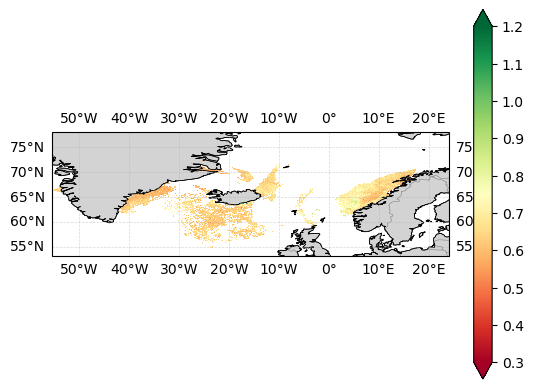

In [6]:
lat = ds["latitude"]
lon = ds["longitude"]
converged = ds["converged"]
sif_radiance_678nm = ds["sif_radiance_678nm"]
sif_radiance_678nm_conv = np.where(converged==1, sif_radiance_678nm, np.nan)

# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# Set global extent
buffer_bnd = .25
lon_min = np.min(lon) - buffer_bnd
lon_max = np.max(lon) + buffer_bnd
lat_min = np.min(lat) - buffer_bnd
lat_max = np.max(lat) + buffer_bnd
extend = [lon_min, lon_max, lat_min, lat_max]
# ax.set_extent(extend, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon, lat, sif_radiance_678nm, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = 0.3,
                 vmax = 1.2,
                #  levels=np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

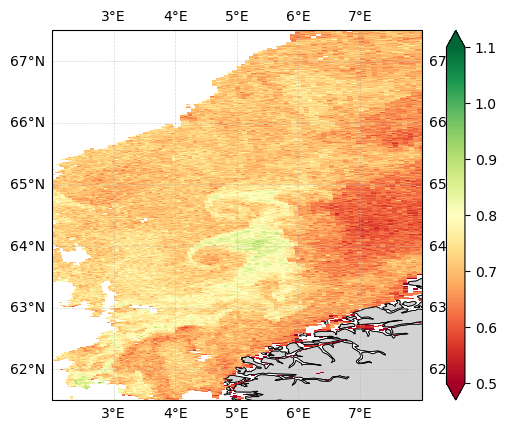

In [11]:
lat = ds["latitude"]
lon = ds["longitude"]
converged = ds["converged"]
sif_radiance_678nm = ds["sif_radiance_678nm"]
sif_radiance_678nm_conv = np.where(converged==1, sif_radiance_678nm, np.nan)

# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

extent1 = [2, 8, 61.5, 67.5]
ax.set_extent(extent1, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon, lat, sif_radiance_678nm, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = 0.5,
                 vmax = 1.1,
                #  levels=np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

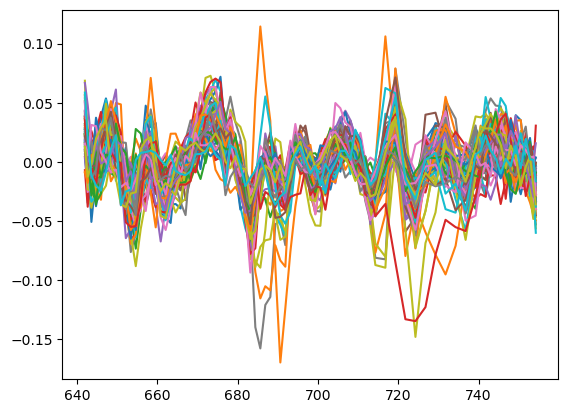

In [16]:
red_wavelength = ds["red_wavelength"]
rmse_reshape = rmse.values.reshape(rmse.shape[0], rmse.shape[1]*rmse.shape[2])
idx = np.where(rmse_reshape[0,:]>=-np.inf)[0]

plt.plot(red_wavelength, rmse_reshape[:,idx[::6000]])

In [17]:
# load L2 AOP and BGC data - nflh and chlor_a
granule_id = '20250927T123954'
dir_aop = "/home/zhe2/data/PACE/L2_AOP_V3.1/"
dir_bgc = "/home/zhe2/data/PACE/L2_BGC_V3.1/"
file_aop = dir_aop + "PACE_OCI." + granule_id + ".L2.OC_AOP.V3_1.nc"
file_bgc = dir_bgc + "PACE_OCI." + granule_id + ".L2.OC_BGC.V3_1.nc"
dtr_aop = xr.open_datatree(file_aop)
ds_aop = xr.merge(dtr_aop.to_dict().values())
dtr_bgc = xr.open_datatree(file_bgc)
ds_bgc = xr.merge(dtr_bgc.to_dict().values())

# lat and lon
lat_l2 = ds_bgc['latitude'].values
lon_l2 = ds_bgc['longitude'].values
# chlor_a
chlor_a = ds_bgc['chlor_a'].values
# nflh
nflh = ds_aop['nflh'].values
# phytoplankton carbon
phyto_c = ds_bgc['carbon_phyto'].values
# poc
poc = ds_bgc['poc'].values

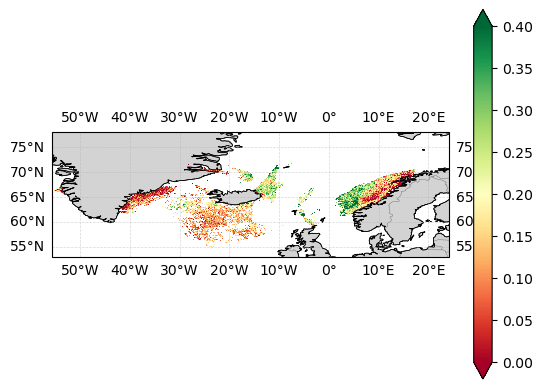

In [18]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

ax.set_extent(extend, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon_l2, lat_l2, nflh, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = 0.,
                 vmax = 0.4,
                #  levels = np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

In [19]:
# check another batch retrieval file
file1 = "/home/zhe2/data/PACE/xSec_fit_output/interim_20250927T123954_retrieval_full_parallel.nc"
ds1 = xr.open_dataset(file1)
# loc
lat_ds1 = ds1['latitude'].values
lon_ds1 = ds1['longitude'].values
# sif 678 nm
sif_678_ds1 = ds1['sif_radiance_678nm'].values


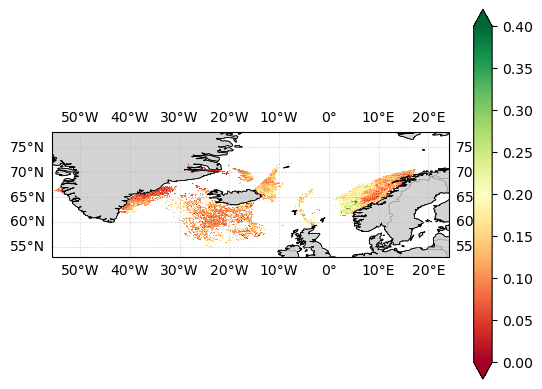

In [20]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

ax.set_extent(extend, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon_ds1, lat_ds1, sif_678_ds1, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = 0.,
                 vmax = 0.4,
                #  levels = np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

In [21]:
# subtract from my retrieval
delta_sif = sif_radiance_678nm - sif_678_ds1
# only convolved
delta_sif_conv = np.where(converged==1, delta_sif, np.nan)

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        3.000e+00, 2.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 1.000e+00,
        2.000e+00, 2.000e+00, 2.000e+00, 1.000e+00, 1.000e+00, 3.000e+00,
        2.000e+00, 3.000e+00, 2.000e+00, 4.000e+00, 0.000e+00, 1.000e+00,
        3.000e+00, 5.000e+00, 7.000e+00, 2.000e+00, 4.000e+00, 1.100e+01,
        1.200e+01, 2.000e+01, 2.600e+01, 5.500e+01, 5.400e+01, 9.400e+01,
        1.280e+02, 1.690e+02, 2.340e+02, 3.310e+02, 4.460e+02, 5.910e+02,
        7.670e+02, 9.890e+02, 1.196e+03, 1.388e+03, 1.702e+03, 1.930e+03,
        2.248e+03, 2.520e+03, 2.706e+03, 2.910e+03, 3.051e+03, 3.248e+03,
        3.146e+03, 3.114e+03, 3.041e+03, 2.808e+03, 2.668e+03, 2.284e+03,
        2.126e+03, 1.695e+03, 1.591e+03, 1.322e+03, 1.102e+03, 8.290e+02,
        6.860e+02, 5.040e+02, 3.980e+0

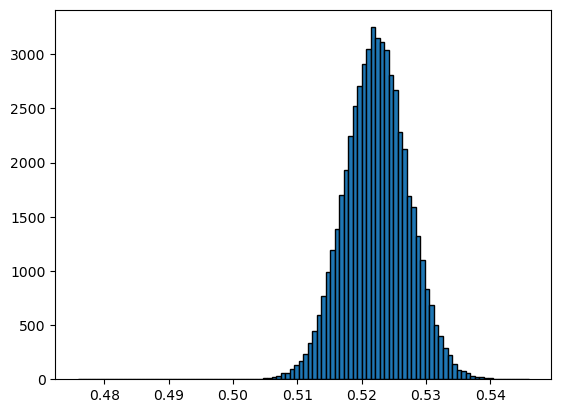

In [23]:
# histogram
plt.hist(delta_sif_conv.flatten(), bins=100, edgecolor='black')

(array([2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 3.0000e+00, 3.0000e+00, 2.0000e+00, 1.0000e+00,
        0.0000e+00, 3.0000e+00, 5.0000e+00, 9.0000e+00, 6.0000e+00,
        1.3000e+01, 1.3000e+01, 1.7000e+01, 1.7000e+01, 2.7000e+01,
        3.4000e+01, 3.8000e+01, 4.8000e+01, 8.3000e+01, 1.0500e+02,
        1.7000e+02, 2.2500e+02, 3.7700e+02, 7.1400e+02, 1.5140e+03,
        2.9030e+03, 5.7590e+03, 1.0632e+04, 1.7226e+04, 2.5559e+04,
        3.3863e+04, 4.0276e+04, 4.2569e+04, 4.0621e+04, 3.5156e+04,
        2.7922e+04, 2.0822e+04, 1.4353e+04, 9.97

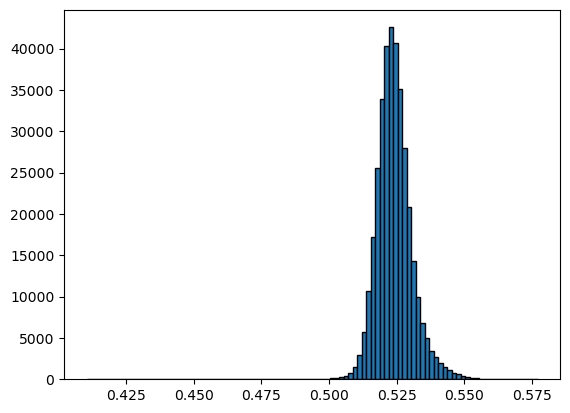

In [25]:
# all 
plt.hist(delta_sif.values.flatten(), bins=100, edgecolor='black')